# (27) animation — mnist to imgnet (save png)

**Motivation**: host = ```mach```, device = ```cuda:1``` <br>

In [1]:
# HIDE CODE


import os, sys
from IPython.display import display

# tmp & extras dir
git_dir = os.path.join(os.environ['HOME'], 'Dropbox/git')
extras_dir = os.path.join(git_dir, 'jb-vae/_extras')
fig_base_dir = os.path.join(git_dir, 'jb-vae/figs')
tmp_dir = os.path.join(git_dir, 'jb-vae/tmp')

# GitHub
sys.path.insert(0, os.path.join(git_dir, '_IterativeVAE/iclr_submitted'))
from figures.fighelper import *
from vae.train_vae import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
from analysis.chosen import *
from figures.analysis import *
from analysis.final import save_both_row_col

from figures.animate import plot_frame

device_idx = 1
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:1  ———  host: mach

In [3]:
dpi = 150

fig_dir = pjoin(fig_base_dir, 'animation/material', f'mnist-to-imgnet_dpi-{dpi}')
os.makedirs(fig_dir, exist_ok=True)
print(len(os.listdir(fig_dir)))

kws_fig = {
    'transparent': False,
    'bbox_inches': 'tight',
    'dpi': dpi,
}

0

## Load data

In [4]:
data = pjoin(tmp_dir, 'mnist-to-imgnet-data.npy')
data = np.load(data, allow_pickle=True).item()

## Plot (sanity check)

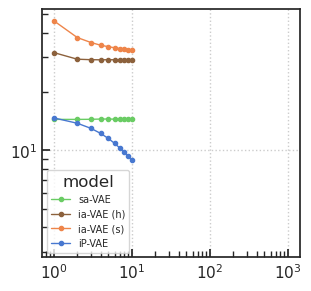

In [5]:
fig, ax = create_figure(1, 1, (3.0, 2.8))

t = 10
pal_models = get_palette_models()

for name, mse in data['mse_data'].items():
    ax = convergence_subplot(ax, mse[:t], name, color=pal_models[name], legend_title='model', legend=True)
ax.tick_params(direction='in', which='both')
sns.move_legend(ax, 'lower left', fontsize=7)
# ax.tick_params(axis='y', labelsize=0)
ax.set(
    xlim=(0.71, 1412.53),
    ylim=(2.80, 53.00),
)
# move_legend(ax, (1, 1.035))
ax.grid()

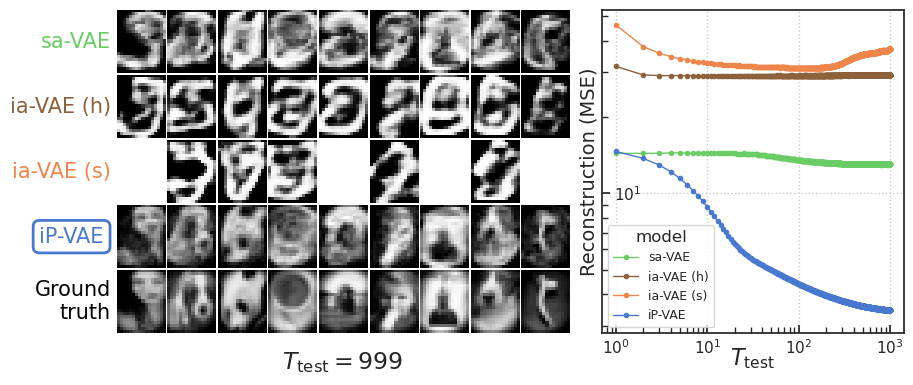

In [6]:
fig = plot_frame(999, data['mse_data'], data['recon_data_cropped'], display=True)

## Save PNG

In [7]:
print(fig_dir)
os.listdir(fig_dir)

/home/hadi/Dropbox/git/jb-vae/figs/animation/material/mnist-to-imgnet_dpi-150

[]

In [8]:
for t in tqdm(range(1000)):
    fig = plot_frame(t, data['mse_data'], data['recon_data_cropped'], display=False)
    fig.savefig(pjoin(fig_dir, f'mnist-to-imgnet_t={t}.png'), **kws_fig)

100%|███████████████████████████████████████| 1000/1000 [13:30<00:00,  1.23it/s]
